In [46]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sat Jun  4 21:33:25 2022

@author: ixn004
"""
#July 10, 2025


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

#from pyswarm import pso
from pyswarms.single.global_best import GlobalBestPSO #Date: Macrh 30,2024
from calculate_pZAP import run_bionetgen
from interpolation import spline
from ca_ODE import calcium, solve
from interpolation_exp_data import exp_idata


from data_slice import data_after_tstart
from ZAP_SYK_SSR_fit import calculate_residue
from calculate_SSR_gamma import gamma_PZAP
from calculate_SSR_zeta import zeta_PZAP    
from calculate_SSR_mixed import mixed_PZAP
import sys
      


In [47]:
# data_gamma=pd.read_csv('../hCD16_Ca_expt/ca_data/gamma.dat',sep="\t", comment='#', header=None)
# data_zeta=pd.read_csv('../hCD16_Ca_expt/ca_data/zeta.dat',sep="\t", comment='#', header=None)
# data_mixed=pd.read_csv('../hCD16_Ca_expt/ca_data/mixed.dat',sep="\t", comment='#', header=None)


data_gamma=pd.read_csv('../../../hCD16_Ca_expt/ca_data/scaled_data/gamma_scaled.dat',sep="\t", comment='#', header=None)
data_zeta=pd.read_csv('../../../hCD16_Ca_expt/ca_data/scaled_data/zeta_scaled.dat',sep="\t", comment='#', header=None)
data_mixed=pd.read_csv('../../../hCD16_Ca_expt/ca_data/scaled_data/mixed_scaled.dat',sep="\t", comment='#', header=None)

global exp_time_gamma, exp_data_gamma, exp_time_zeta, exp_data_zeta, exp_time_mixed, exp_data_mixed
#if the data has a time column:
start_time=time.time()

data_gamma=np.asarray(data_gamma) 
data_zeta=np.asarray(data_zeta)
data_mixed=np.asarray(data_mixed)

exp_time_gamma=data_gamma[:,0]
exp_data_gamma=data_gamma[:,1]

exp_time_zeta=data_zeta[:,0]
exp_data_zeta=data_zeta[:,1]

exp_time_mixed=data_mixed[:,0]
exp_data_mixed=data_mixed[:,1]


In [48]:



a0_zeta=150
a0_mixed= a0_zeta*1.6 
a0_gamma= a0_zeta*0.53
ZAP0= 1131.0
SYK0= 754.0

C1_optimal = 2.6276e+04
C2_optimal = 2.3378e-01
g_optimal = 7.1257e-03
k3_optimal = 4.0315e-02
k4_optimal = 3.5377e-02

C1=C1_optimal
C2=C2_optimal
g=g_optimal
k3=k3_optimal
k4=k4_optimal

dir_name="analysis"
print(f"C1={C1}")
print(f"C2={C2}")
print(f"g={g}")
print(f'k3_optimal={k3_optimal}')
print(f'k4_optimal={k4_optimal}')


print(f"a0_zeta={a0_zeta}")
print(f"a0_mixed={a0_mixed}")
print(f"a0_gamma={a0_gamma}")
print(f"ZAP0={ZAP0}")
print(f"SYK0={SYK0}")


C1=26276.0
C2=0.23378
g=0.0071257
k3_optimal=0.040315
k4_optimal=0.035377
a0_zeta=150
a0_mixed=240.0
a0_gamma=79.5
ZAP0=1131.0
SYK0=754.0


In [49]:
zeta=pd.read_csv('zeta_results.txt',sep='\t',header=None)
tnew_zeta = zeta.iloc[:, 0].values
PZAP_zeta = zeta.iloc[:,1].values
PSYK_zeta = zeta.iloc[:,2].values

# print("tnew_zeta:", tnew_zeta)
# print("PZAP_zeta:", PZAP_zeta)
# print("PSYK_zeta:", PSYK_zeta)

mixed=pd.read_csv('mixed_results.txt',sep='\t',header=None)
tnew_mixed = mixed.iloc[:, 0].values
PZAP_mixed = mixed.iloc[:,1].values
PSYK_mixed = mixed.iloc[:,2].values

gamma=pd.read_csv('gamma_results.txt',sep='\t',header=None)
tnew_gamma = gamma.iloc[:, 0].values
PZAP_gamma = gamma.iloc[:,1].values
PSYK_gamma = gamma.iloc[:,2].values



In [50]:
n=3
N=2000


In [51]:


residue_zeta,t_zeta,EXPT_zeta,Ca_zeta = calculate_residue(n, tnew_zeta, PZAP_zeta, PSYK_zeta, exp_time_zeta, exp_data_zeta, C1, C2, g, N, k3,k4)
residue_mixed,t_mixed,EXPT_mixed,Ca_mixed = calculate_residue(n, tnew_mixed, PZAP_mixed, PSYK_mixed, exp_time_mixed, exp_data_mixed, C1, C2, g, N, k3,k4)
residue_gamma,t_gamma,EXPT_gamma,Ca_gamma = calculate_residue(n, tnew_gamma, PZAP_gamma, PSYK_gamma, exp_time_gamma, exp_data_gamma, C1, C2, g, N, k3,k4)

ca0 in main 38689.53125
[38689.53125    38652.86352061 38616.23477211 ... 22000.00009828
 21979.1500052  21958.31967247]
ca0 in main 41737.61328
[41737.61328    41698.05780898 41658.56520461 ... 22395.50668449
 22374.28175654 22353.07694417]
ca0 in main 36345.51172
[36345.51172    36311.06551853 36276.65195378 ... 23504.01721227
 23481.74248846 23459.48887443]


Total residue^(1/4) = 950.9917


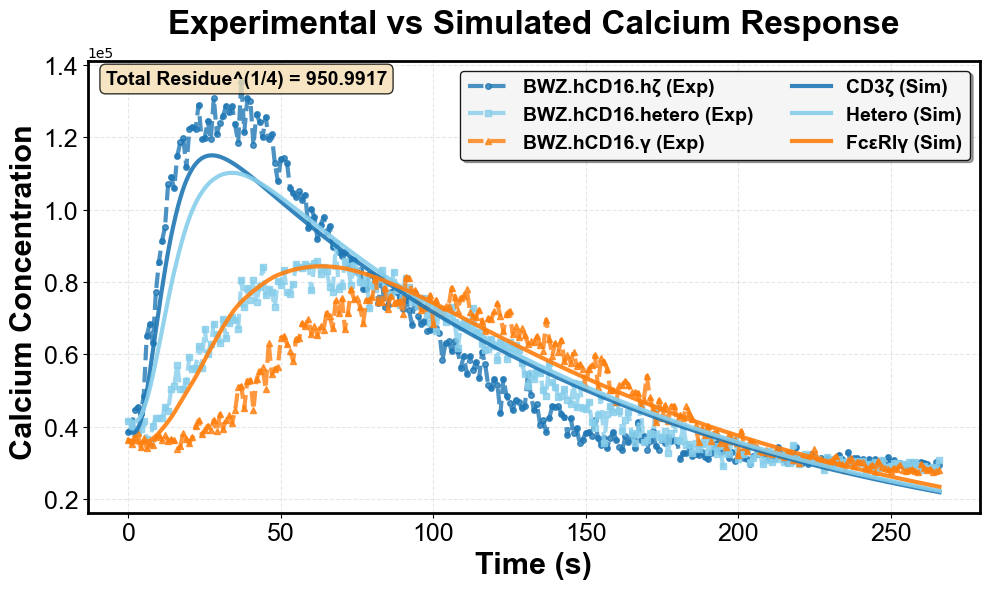

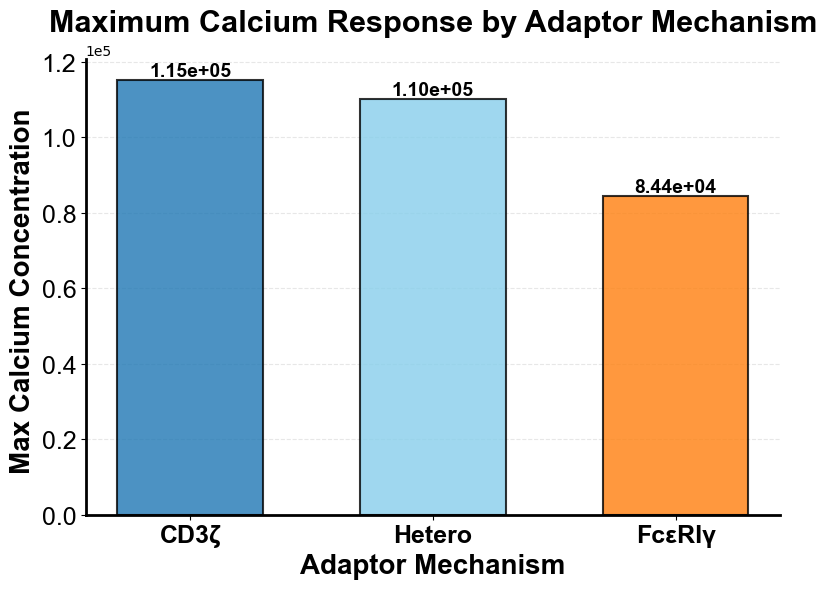

In [52]:
Vc=25.0 #pZAP molecules in the simulation box of size 25 um^3
z=602.0 #constant factor to convert from molecules/um3 to uM

# Enhanced experimental vs simulation calcium plot
fig, ax = plt.subplots(figsize=(10, 6))


# Experimental data with enhanced styling
ax.plot(exp_time_zeta, exp_data_zeta, color='#1f77b4', linewidth=3, 
        linestyle='--', alpha=0.8, label='BWZ.hCD16.hζ (Exp)', marker='o', markersize=4)
ax.plot(exp_time_mixed, exp_data_mixed, color='#87ceeb', linewidth=3, 
        linestyle='--', alpha=0.8, label='BWZ.hCD16.hetero (Exp)', marker='s', markersize=4)
ax.plot(exp_time_gamma, exp_data_gamma, color='#ff7f0e', linewidth=3, 
        linestyle='--', alpha=0.8, label='BWZ.hCD16.γ (Exp)', marker='^', markersize=4)

# Simulation data with solid lines
ax.plot(t_zeta, Ca_zeta, color='#1f77b4', linewidth=3, alpha=0.9, label='CD3ζ (Sim)')
ax.plot(t_mixed, Ca_mixed, color='#87ceeb', linewidth=3, alpha=0.9, label='Hetero (Sim)')
ax.plot(t_gamma, Ca_gamma, color='#ff7f0e', linewidth=3, alpha=0.9, label='FcεRIγ (Sim)')

# Calculate and display residue
# Calculate and display residue
#residue_total = residue_zeta #+ residue_gamma
residue_total = residue_zeta  + residue_mixed + residue_gamma
print(f"Total residue^(1/4) = {residue_total**(1/4):.4f}")

# Enhanced labels and title
ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_ylabel('Calcium Concentration ', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_title('Experimental vs Simulated Calcium Response', 
             fontfamily='Arial', fontsize=24, fontweight='bold', pad=20)

# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Enhanced legend with two columns
legend = ax.legend(prop={'family': 'Arial', 'size': 14, 'weight': 'bold'}, 
                   frameon=True, fancybox=True, shadow=True, 
                   framealpha=0.9, edgecolor='black', ncol=2, loc='upper right')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set spine styling
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Scientific notation if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Add text box with residue information
textstr = f'Total Residue^(1/4) = {residue_total**(1/4):.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props, fontfamily='Arial', fontweight='bold')

plt.tight_layout()
plt.show()

# Enhanced maximum calcium bar plot
fig, ax = plt.subplots(figsize=(8, 6))

# Data and labels
mechanisms = ['CD3ζ', 'Hetero', 'FcεRIγ']
max_calcium_values = [np.max(Ca_zeta), np.max(Ca_mixed), np.max(Ca_gamma)]
colors = ['#1f77b4', '#87ceeb', '#ff7f0e']  # Professional color palette

# Create bars with enhanced styling
bars = ax.bar(mechanisms, max_calcium_values, 
              color=colors, 
              alpha=0.8,
              edgecolor='black',
              linewidth=1.5,
              width=0.6)

# Add value labels on top of bars
for bar, value in zip(bars, max_calcium_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.2e}',
            ha='center', va='bottom', 
            fontfamily='Arial', fontsize=14, fontweight='bold')

# Customize the plot
ax.set_ylabel('Max Calcium Concentration ', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_xlabel('Adaptor Mechanism', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_title('Maximum Calcium Response by Adaptor Mechanism', 
             fontfamily='Arial', fontsize=22, fontweight='bold', pad=20)

# Set tick parameters
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial', fontweight='bold')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_axisbelow(True)

# Set spine thickness and style
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Scientific notation for y-axis
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Adjust layout and show
plt.tight_layout()
plt.show()
